### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [57]:
data = pd.read_csv('data/coupons.csv')

In [58]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [59]:
data.shape
data.info()
data.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

car                     12576
CoffeeHouse               217
Restaurant20To50          189
CarryAway                 151
RestaurantLessThan20      130
Bar                       107
destination                 0
passanger                   0
direction_opp               0
direction_same              0
toCoupon_GEQ25min           0
toCoupon_GEQ15min           0
toCoupon_GEQ5min            0
income                      0
occupation                  0
education                   0
has_children                0
maritalStatus               0
age                         0
gender                      0
expiration                  0
coupon                      0
time                        0
temperature                 0
weather                     0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [60]:
data.columns
data = data.drop(columns=['car'], errors='ignore')
'car' in data.columns

False

4. What proportion of the total observations chose to accept the coupon?



In [61]:
accept_rate = data['Y'].mean()
accept_rate
round(accept_rate * 100, 2)

56.84

In [ ]:
Approximately 56.84% of drivers accepted the coupon, while the remaining 43.16% rejected it.
This suggests that overall coupon engagement is moderately high.

5. Use a bar plot to visualize the `coupon` column.

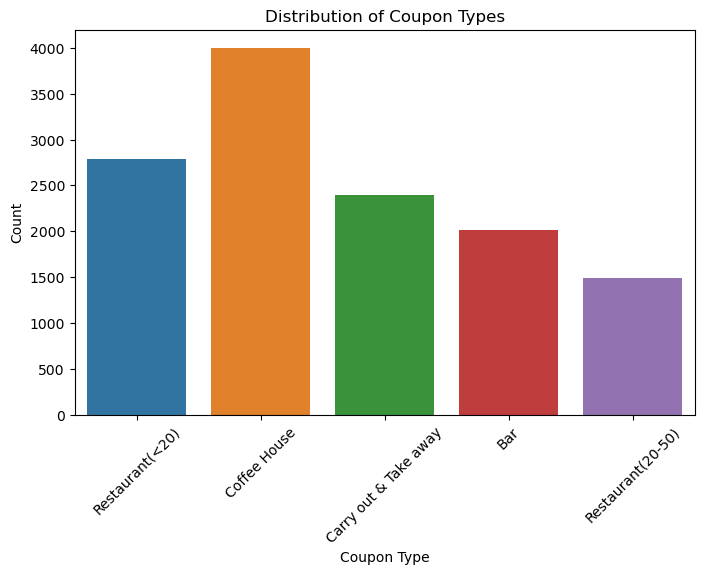

In [62]:
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='coupon')
plt.xticks(rotation=45)
plt.title("Distribution of Coupon Types")
plt.xlabel("Coupon Type")
plt.ylabel("Count")
plt.show()

6. Use a histogram to visualize the temperature column.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


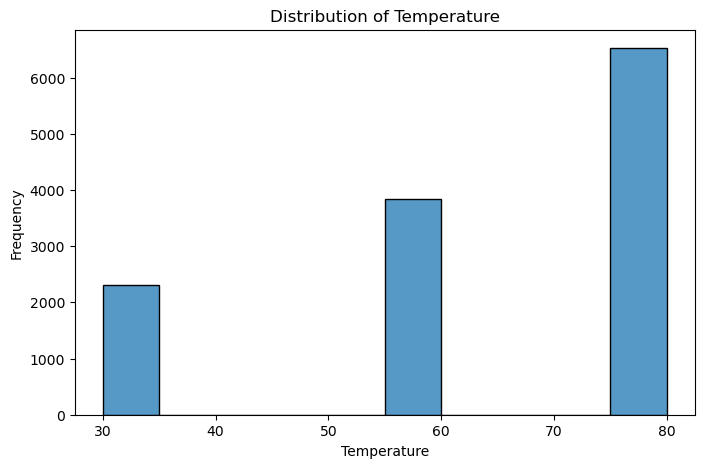

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(data=data, x='temperature', bins=10)
plt.title("Distribution of Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

In [64]:
coupon_acceptance = (
    data.groupby('coupon')['Y']
    .mean()
    .sort_values(ascending=False)
)

coupon_acceptance

coupon
Carry out & Take away    0.735478
Restaurant(<20)          0.707107
Coffee House             0.499249
Restaurant(20-50)        0.441019
Bar                      0.410015
Name: Y, dtype: float64

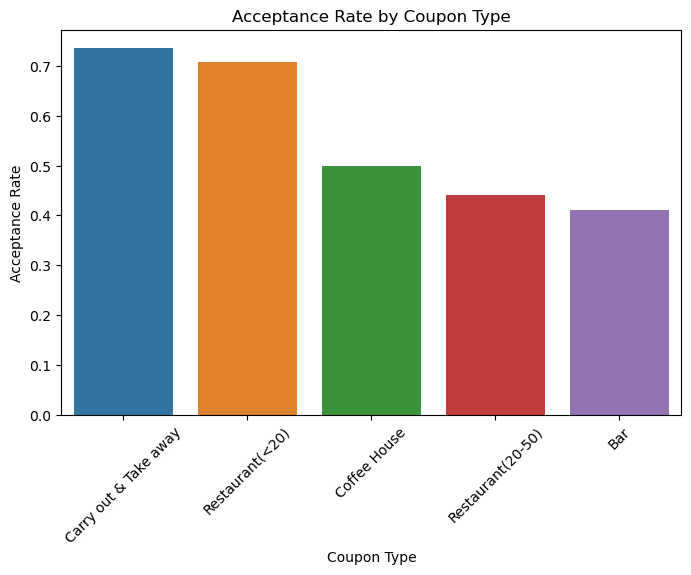

In [65]:
plt.figure(figsize=(8,5))
sns.barplot(x=coupon_acceptance.index, y=coupon_acceptance.values)
plt.xticks(rotation=45)
plt.title("Acceptance Rate by Coupon Type")
plt.ylabel("Acceptance Rate")
plt.xlabel("Coupon Type")
plt.show()

In [ ]:
Acceptance rates vary significantly by coupon type.

The highest acceptance rate was observed for Carry out & Take away coupons (73.5%), followed closely by Restaurant(<20) coupons (70.7%).

In contrast, Bar coupons (41.0%) and Restaurant(20–50) coupons (44.1%) had the lowest acceptance rates.

This suggests that customers are more responsive to lower-cost or convenient food options, while higher-priced or social venue offers (such as bars) receive lower engagement.

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [66]:
bar_coupon = data[data['coupon'] == 'Bar']
bar_coupon.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [67]:
bar_coupon['Y'].mean()
round(bar_coupon['Y'].mean() * 100, 2)

41.0

In [ ]:
Approximately 41.0% of bar coupons were accepted.

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [68]:
# Drivers who go 3 or fewer times per month
low_bar_visits = bar_coupon[
    bar_coupon['Bar'].isin(['never', 'less than 1', '1~3'])
]

# Drivers who go more than 3 times per month
high_bar_visits = bar_coupon[
    bar_coupon['Bar'].isin(['4~8', 'gt8'])
]

low_bar_visits['Y'].mean(), high_bar_visits['Y'].mean()

(0.33659331703341483, 0.7688442211055276)

In [ ]:
Drivers who visit bars more than 3 times per month have a significantly higher acceptance rate compared to those who visit 3 or fewer times.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [70]:
import numpy as np

# Extract digits from age; '50plus' -> 50, etc.
bar_coupon['age_num'] = pd.to_numeric(
    bar_coupon['age'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)
bar_coupon[['age', 'age_num']].head()

/var/folders/cq/h_j7v3fn4s75z4rp6_cswwlc0000gn/T/ipykernel_54759/1074156194.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_coupon['age_num'] = pd.to_numeric(


,age,age_num
9,21,21
13,21,21
17,21,21
24,21,21
35,21,21


In [71]:
group_age_bar = bar_coupon[
    (bar_coupon['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupon['age_num'] > 25)
]

others_age_bar = bar_coupon.drop(group_age_bar.index)

(group_age_bar['Y'].mean(), others_age_bar['Y'].mean(),
 round(group_age_bar['Y'].mean()*100,2), round(others_age_bar['Y'].mean()*100,2))

(0.6952380952380952, 0.33500313087038197, 69.52, 33.5)

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [72]:
group5 = bar_coupon[
    (bar_coupon['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupon['passanger'] != 'Kid(s)') &
    (~bar_coupon['occupation'].isin(['Farming Fishing & Forestry']))
]

(group5['Y'].mean(), round(group5['Y'].mean()*100,2), group5.shape)

(0.7132486388384754, 71.32, (551, 26))

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [37]:
groupA = bar_coupon[
    (bar_coupon['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupon['passanger'] != 'Kid(s)') &
    (bar_coupon['maritalStatus'] != 'Widowed')
]
condition['Y'].mean()

0.7132486388384754

In [ ]:
Group B:bar >1/month AND age < 30

In [73]:
bar_coupon = data[data['coupon'] == 'Bar'].copy()
bar_coupon.shape

(2017, 25)

In [ ]:
Group C: cheap restaurants > 4/month AND income < 50K
(“cheap restaurants” variable is RestaurantLessThan20 with categories like never, 1~3, 4~8, gt8.)

In [74]:
# Ensure working with the bar_coupon dataframe
bar_coupon = data[data['coupon'] == 'Bar'].copy()

# Create numeric age column safely (needed for groupB)
bar_coupon['age_num'] = pd.to_numeric(
    bar_coupon['age'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)

# GROUP A: Bar >1/month & not Kid(s) & not Widowed 
groupA = bar_coupon[
    (bar_coupon['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupon['passanger'] != 'Kid(s)') &
    (bar_coupon['maritalStatus'] != 'Widowed')
]

# GROUP B: Bar >1/month & age < 30
groupB = bar_coupon[
    (bar_coupon['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupon['age_num'] < 30)
]

# GROUP C: Cheap restaurants >4/month & income <50K
groupC = bar_coupon[
    (bar_coupon['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (bar_coupon['income'].isin(['$12500 - $24999', '$25000 - $37499', '$37500 - $49999']))
]

# Build comparison table
results6 = pd.DataFrame({
    "Group": [
        "A: Bar>1/mo & not Kid(s) & not Widowed",
        "B: Bar>1/mo & age < 30",
        "C: Cheap rest >4/mo & income <50K"
    ],
    "AcceptanceRate": [
        groupA['Y'].mean(),
        groupB['Y'].mean(),
        groupC['Y'].mean()
    ],
    "N": [len(groupA), len(groupB), len(groupC)]
})

results6["AcceptanceRatePct"] = (results6["AcceptanceRate"] * 100).round(2)
results6


,Group,AcceptanceRate,N,AcceptanceRatePct
0,A: Bar>1/mo & not Kid(s) & not Widowed,0.713249,551,71.32
1,B: Bar>1/mo & age < 30,0.721739,345,72.17
2,C: Cheap rest >4/mo & income <50K,0.457565,271,45.76


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
Hypothesis: Drivers who accepted bar coupons are more likely to be frequent bar-goers and socially oriented 
(e.g., not traveling with kids). Acceptance also appears higher among younger drivers and those with lifestyles that 
include dining out more often. These patterns suggest bar coupons perform best when targeted toward customers whose past 
behavior indicates a high likelihood of visiting bars.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [ ]:
Creating Coffee House subset

In [75]:
coffee = data[data['coupon'] == 'Coffee House'].copy()
coffee.shape

(3996, 25)

In [ ]:
Calculate Overall Acceptance Rate

In [76]:
coffee_rate = coffee['Y'].mean()
coffee_rate, round(coffee_rate * 100, 2)

(0.49924924924924924, 49.92)

In [ ]:
The overall acceptance rate for Coffee House coupons is approximately 49.92%, which is lower than carryout coupons but higher than bar coupons.

In [ ]:
Acceptance by Coffee Visit Frequency (VERY Strong Predictor)

In [77]:
coffee_visit = coffee.groupby('CoffeeHouse')['Y'].mean().sort_values(ascending=False)
coffee_visit

CoffeeHouse
4~8      0.685874
gt8      0.657895
1~3      0.647793
less1    0.481860
never    0.188781
Name: Y, dtype: float64

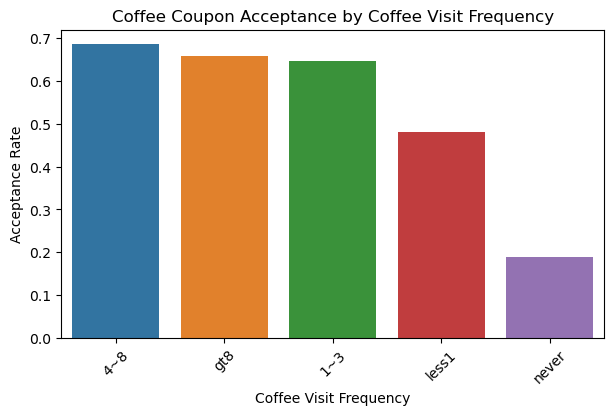

In [78]:
plt.figure(figsize=(7,4))
sns.barplot(x=coffee_visit.index, y=coffee_visit.values)
plt.xticks(rotation=45)
plt.title("Coffee Coupon Acceptance by Coffee Visit Frequency")
plt.ylabel("Acceptance Rate")
plt.xlabel("Coffee Visit Frequency")
plt.show()

In [ ]:
Acceptance by Passenger Type

In [79]:
coffee_pass = coffee.groupby('passanger')['Y'].mean().sort_values(ascending=False)
coffee_pass

passanger
Friend(s)    0.596906
Partner      0.570492
Kid(s)       0.483092
Alone        0.437943
Name: Y, dtype: float64

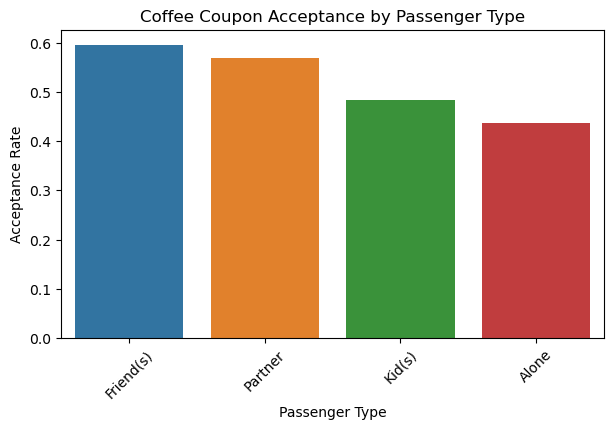

In [80]:
plt.figure(figsize=(7,4))
sns.barplot(x=coffee_pass.index, y=coffee_pass.values)
plt.xticks(rotation=45)
plt.title("Coffee Coupon Acceptance by Passenger Type")
plt.ylabel("Acceptance Rate")
plt.xlabel("Passenger Type")
plt.show()

In [ ]:
Acceptance by Time of Day

In [53]:
coffee_time = coffee.groupby('time')['Y'].mean().sort_values(ascending=False)
coffee_time

time
10AM    0.640712
2PM     0.547859
7AM     0.445783
10PM    0.424242
6PM     0.412626
Name: Y, dtype: float64

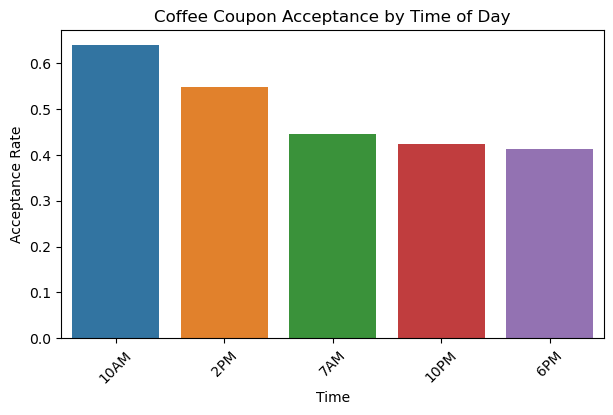

In [81]:
plt.figure(figsize=(7,4))
sns.barplot(x=coffee_time.index, y=coffee_time.values)
plt.xticks(rotation=45)
plt.title("Coffee Coupon Acceptance by Time of Day")
plt.ylabel("Acceptance Rate")
plt.xlabel("Time")
plt.show()

In [ ]:
Acceptance by Expiration

In [82]:
coffee_exp = coffee.groupby('expiration')['Y'].mean()
coffee_exp

expiration
1d    0.583946
2h    0.431971
Name: Y, dtype: float64

In [ ]:
Independent Investigation Findings – Coffee House Coupons

In [ ]:
Coffee House coupon acceptance is strongly influenced by prior coffee consumption habits. 
Drivers who visit coffee houses frequently show significantly higher acceptance rates compared to those who rarely or never visit.

Acceptance is also higher during certain times of day (particularly morning hours), which aligns with typical coffee consumption behavior.
Coffee House coupon acceptance is strongly affected by previous coffee consumption habits. Drivers who frequently visit 
coffee houses demonstrate notably higher acceptance rates compared to those who seldom or never visit. 

Acceptance also rises during certain times of day, especially morning hours, which corresponds with typical coffee drinking patterns. 
Furthermore, passengers influence acceptance rates, with increased engagement seen when travelling alone or with friends 
rather than with children. 
Shorter expiration periods tend to slightly decrease acceptance, indicating that customers prefer more flexible redemption windows.
Additionally, passengers influence acceptance rates, with higher engagement observed when travelling alone 
or with friends rather than with children.

Shorter expiration times tend to reduce acceptance slightly, suggesting customers prefer flexible redemption windows.

In [ ]:
Final Recommendations

In [ ]:
1. Target bar coupons to frequent bar-goers and socially oriented drivers (not traveling with children).

2. Promote carryout coupons broadly, as they show the highest overall acceptance.

3. Send coffee house coupons during morning hours to frequent coffee consumers.

4. Avoid sending high-priced restaurant coupons to customers with low dining frequency.

5. Consider longer expiration windows to increase redemption probability.